# Notebook 4: Build Canada Basemap Grids

## Objectives

This notebook builds Canada-wide basemap grids for spatial aggregation.

The basemap regions will serve as the common spatial indexing layer for later aggregation of roads, infrastructure, industrial facilities, resource potentials, and demand data.

This notebook focuses only on basemap generation and validation. It does not perform graph construction, connectivity analysis, or TEMOA SQL encoding.

In [20]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Point


# Define input and output directories.

RAW_BASEMAP = Path("../data_files/raw/basemaps")
PROCESSED_BASEMAP = Path("../data_files/processed/basemaps")

PROCESSED_BASEMAP.mkdir(
    parents=True,
    exist_ok=True,
)


# Coordinate reference systems.

WGS84_CRS = "EPSG:4326"
CANADA_PROJECTED_CRS = "EPSG:3347"

In [2]:
# Locate the raw province and territory boundary shapefile.

boundary_shapefiles = sorted(
    RAW_BASEMAP.glob("*.shp")
)

if len(boundary_shapefiles) != 1:
    raise ValueError(
        f"Expected exactly one boundary shapefile in {RAW_BASEMAP}, "
        f"found {len(boundary_shapefiles)}: "
        f"{[path.name for path in boundary_shapefiles]}"
    )

province_boundary_path = boundary_shapefiles[0]

print(f"Using boundary file: {province_boundary_path.name}")

Using boundary file: lpr_000b21a_e.shp


In [3]:
# Load the Canada province and territory cartographic boundary file.

provinces = gpd.read_file(
    province_boundary_path
)

provinces.head()

,PRUID,DGUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR,LANDAREA,geometry
0,10,2021A000210,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.,3.581704e+05,"MULTIPOLYGON (((8841194.729 2213093.663, 88411..."
1,11,2021A000211,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.,5.681179e+03,"MULTIPOLYGON (((8374335.443 1629502.597, 83743..."
2,12,2021A000212,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.,5.282471e+04,"MULTIPOLYGON (((8310463.217 1250722.263, 83104..."
3,13,2021A000213,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.,7.124850e+04,"MULTIPOLYGON (((7964100.72 1576822.289, 796410..."
4,24,2021A000224,Quebec / Québec,Quebec,Québec,Que.,Qc,1.298600e+06,"MULTIPOLYGON (((6948393.211 2760814.626, 69483..."


In [4]:
# Inspect the loaded boundary file.

print(provinces.crs)
print(provinces.shape)
print(provinces.columns.tolist())

provinces.head()

EPSG:3347
(13, 9)
['PRUID', 'DGUID', 'PRNAME', 'PRENAME', 'PRFNAME', 'PREABBR', 'PRFABBR', 'LANDAREA', 'geometry']


,PRUID,DGUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR,LANDAREA,geometry
0,10,2021A000210,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.,3.581704e+05,"MULTIPOLYGON (((8841194.729 2213093.663, 88411..."
1,11,2021A000211,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.,5.681179e+03,"MULTIPOLYGON (((8374335.443 1629502.597, 83743..."
2,12,2021A000212,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.,5.282471e+04,"MULTIPOLYGON (((8310463.217 1250722.263, 83104..."
3,13,2021A000213,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.,7.124850e+04,"MULTIPOLYGON (((7964100.72 1576822.289, 796410..."
4,24,2021A000224,Quebec / Québec,Quebec,Québec,Que.,Qc,1.298600e+06,"MULTIPOLYGON (((6948393.211 2760814.626, 69483..."


In [5]:
# Inspect province and territory identifiers.

provinces[
    [
        column
        for column in provinces.columns
        if "PR" in column.upper() or "NAME" in column.upper()
    ]
].head()

,PRUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR
0,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.
1,11,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.
2,12,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.
3,13,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.
4,24,Quebec / Québec,Quebec,Québec,Que.,Qc


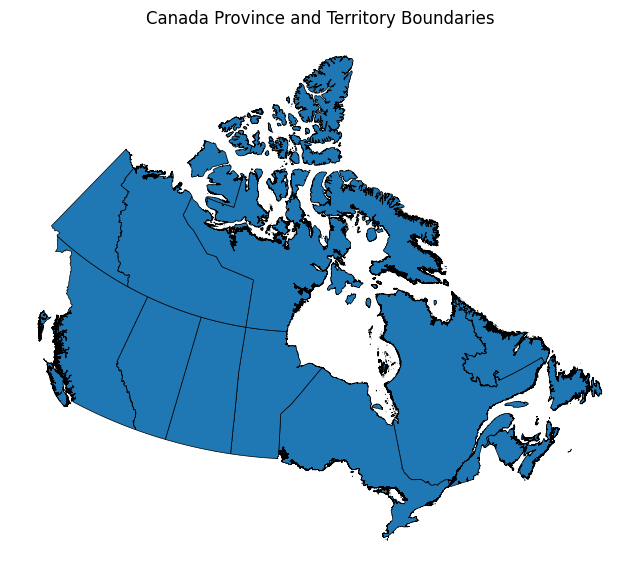

In [6]:
# Plot the province and territory boundary file.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

provinces.plot(
    ax=ax,
    linewidth=0.5,
    edgecolor="black",
)

ax.set_title("Canada Province and Territory Boundaries")
ax.set_axis_off()

plt.show()

In [7]:
# Reproject province and territory boundaries to WGS84.

provinces_wgs84 = provinces.to_crs(
    WGS84_CRS
)

print(provinces_wgs84.crs)

EPSG:4326


In [8]:
# Dissolve province and territory boundaries into a single Canada polygon.
# Construct a single Canada land boundary.

canada_geometry = (
    provinces_wgs84.geometry
    .union_all()
)

canada_boundary = gpd.GeoDataFrame(
    {
        "name": ["Canada"],
    },
    geometry=[canada_geometry],
    crs=WGS84_CRS,
)

canada_boundary

,name,geometry
0,Canada,"MULTIPOLYGON (((-132.53304 53.04474, -132.5330..."


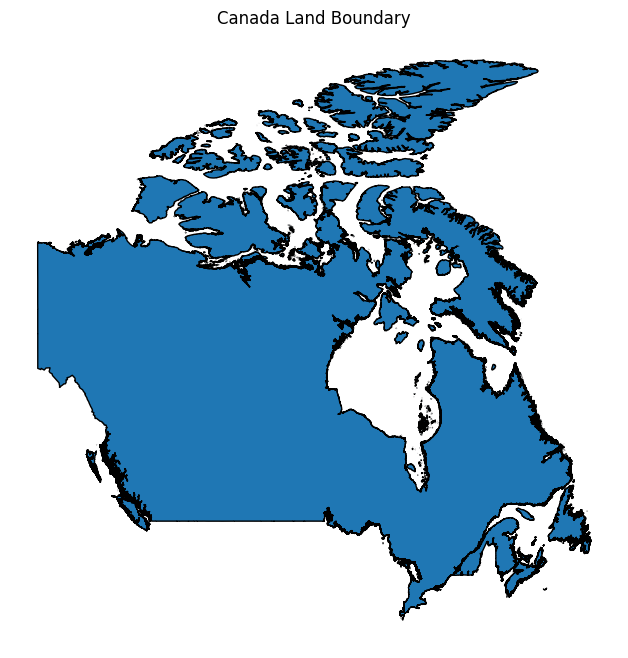

In [9]:
# Plot the dissolved Canada boundary.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

canada_boundary.plot(
    ax=ax,
    edgecolor="black",
)

ax.set_title(
    "Canada Land Boundary"
)

ax.set_axis_off()

plt.show()

In [10]:
# Define latitude/longitude basemap resolutions.

BASEMAP_RESOLUTIONS = [
    0.1,
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
]

In [25]:
# Build a regular latitude/longitude basemap grid.

def build_latlon_grid(
    boundary: gpd.GeoDataFrame,
    resolution_deg: float,
    keep_method: str = "centroid",
) -> gpd.GeoDataFrame:
    """
    Build a regular latitude/longitude grid over a boundary polygon.

    Args:
        boundary:
            Boundary GeoDataFrame in WGS84.
        resolution_deg:
            Grid resolution in decimal degrees.
        keep_method:
            Method used to retain grid cells. Options are "centroid" or
            "intersects".

    Returns:
        GeoDataFrame containing regular grid cells retained by the selected
        boundary rule.
    """

    min_lon, min_lat, max_lon, max_lat = boundary.total_bounds

    lon_values = np.arange(
        np.floor(min_lon),
        np.ceil(max_lon),
        resolution_deg,
    )

    lat_values = np.arange(
        np.floor(min_lat),
        np.ceil(max_lat),
        resolution_deg,
    )

    grid_cells = []

    for lon_min in lon_values:
        for lat_min in lat_values:

            lon_center = round(
                lon_min + resolution_deg / 2,
                6,
            )
            lat_center = round(
                lat_min + resolution_deg / 2,
                6,
            )

            grid_cells.append(
                {
                    "lon_min": round(lon_min, 6),
                    "lon_max": round(lon_min + resolution_deg, 6),
                    "lat_min": round(lat_min, 6),
                    "lat_max": round(lat_min + resolution_deg, 6),
                    "lon": lon_center,
                    "lat": lat_center,
                    "geometry": box(
                        lon_min,
                        lat_min,
                        lon_min + resolution_deg,
                        lat_min + resolution_deg,
                    ),
                    "centroid_geometry": Point(
                        lon_center,
                        lat_center,
                    ),
                }
            )

    grid = gpd.GeoDataFrame(
        grid_cells,
        geometry="geometry",
        crs=WGS84_CRS,
    )

    canada_geometry = boundary.geometry.union_all()

    if keep_method == "centroid":
        centroid_points = gpd.GeoSeries(
            grid["centroid_geometry"],
            crs=WGS84_CRS,
        )

        grid = grid.loc[
            centroid_points.within(canada_geometry)
        ].copy()

    elif keep_method == "intersects":
        grid = grid.loc[
            grid.geometry.intersects(canada_geometry)
        ].copy()

    else:
        raise ValueError(
            "keep_method must be either 'centroid' or 'intersects'."
        )

    grid = grid.drop(
        columns="centroid_geometry"
    )

    grid = grid.sort_values(
        by=[
            "lat",
            "lon",
        ]
    ).reset_index(
        drop=True
    )

    grid["region"] = [
        f"R{i}" for i in grid.index
    ]

    grid["site_id"] = grid["region"]

    grid["resolution_deg"] = resolution_deg
    grid["keep_method"] = keep_method

    return grid

In [ ]:
# Build 1° basemaps using different retention methods.

canada_basemap_1deg_centroid = build_latlon_grid(
    canada_boundary,
    resolution_deg=1.0,
    keep_method="centroid",
)

canada_basemap_1deg_intersects = build_latlon_grid(
    canada_boundary,
    resolution_deg=1.0,
    keep_method="intersects",
)

print(canada_basemap_1deg_centroid.shape)
print(canada_basemap_1deg_intersects.shape)

(1692, 11)
(2276, 11)


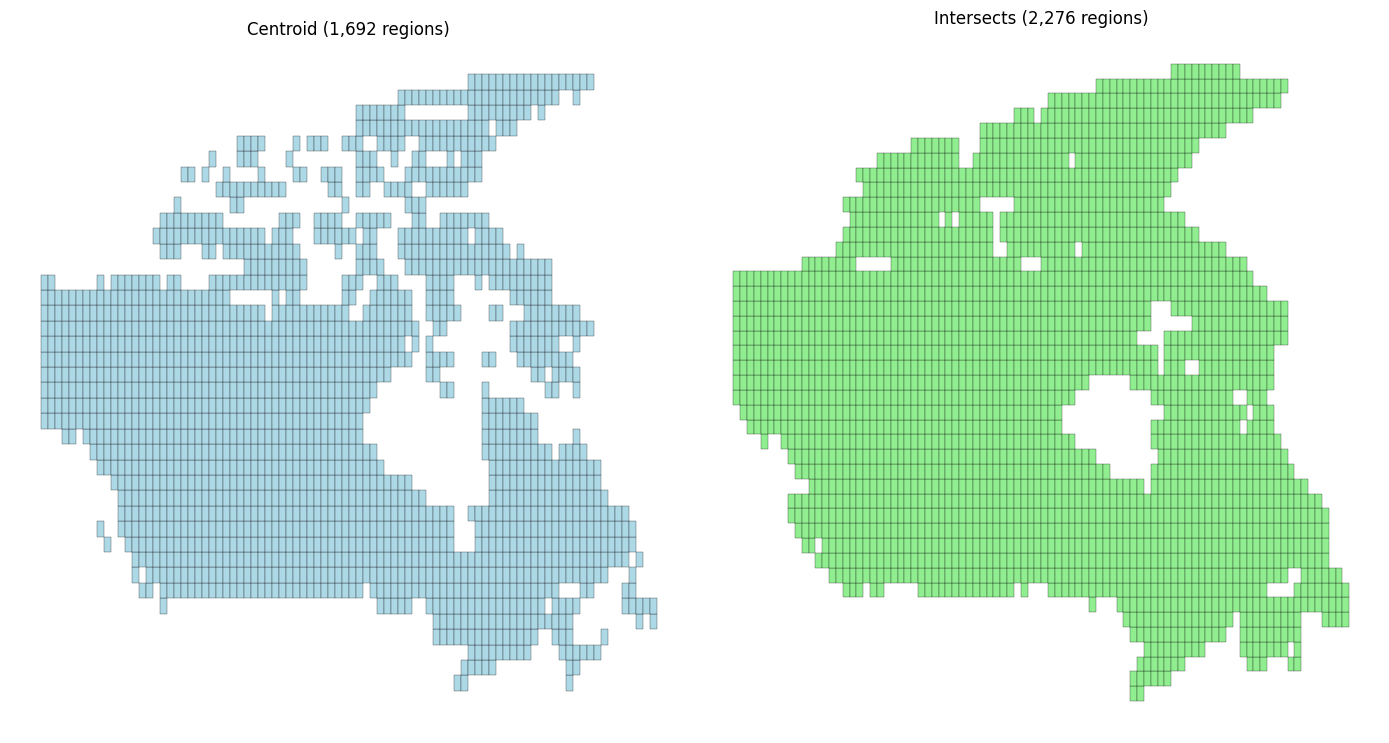

In [27]:
# Plot 1° basemaps for comparison.

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 8),
)

canada_basemap_1deg_centroid.plot(
    ax=axes[0],
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.2,
)

axes[0].set_title(
    f"Centroid ({len(canada_basemap_1deg_centroid):,} regions)"
)

axes[0].set_axis_off()


canada_basemap_1deg_intersects.plot(
    ax=axes[1],
    facecolor="lightgreen",
    edgecolor="black",
    linewidth=0.2,
)

axes[1].set_title(
    f"Intersects ({len(canada_basemap_1deg_intersects):,} regions)"
)

axes[1].set_axis_off()

plt.tight_layout()

plt.show()